# Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

import joblib

# Task 1 : Data Loading & Exploratory Data Analysis

## 1.1 Task : Load & Filter the Dataset

## Load Dataset

In [2]:
original_data = pd.read_csv('../Dataset/online_retail.csv')

df = original_data.copy()

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Basic Info & Shape

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [4]:
df.shape

(1067371, 8)

## Filter

In [5]:
df = df[df["Country"] == "United Kingdom"]

## Dropped rows where CustomerID is Null

In [6]:
df = df.dropna(subset=["Customer ID"])
print("Rows remaining after CustomerID filtering:", len(df))

Rows remaining after CustomerID filtering: 741301


## Drop rows where Quantity <= 0

In [7]:
before = len(df)
df = df[df["Quantity"] > 0]
print("Rows dropped due to Quantity <= 0:", before - len(df))

Rows dropped due to Quantity <= 0: 16005


## Drop rows where UnitPrice <= 0

In [8]:
df = df[df["Price"] > 0]

## Creating TotalPrice Column

In [9]:
df["TotalPrice"] = df["Quantity"] * df["Price"]

## Final dataset

In [10]:
print("Final rows:", len(df))
df.head()

Final rows: 725250


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


## 1.2 : Univariate Analysis

In [11]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

## Histograms

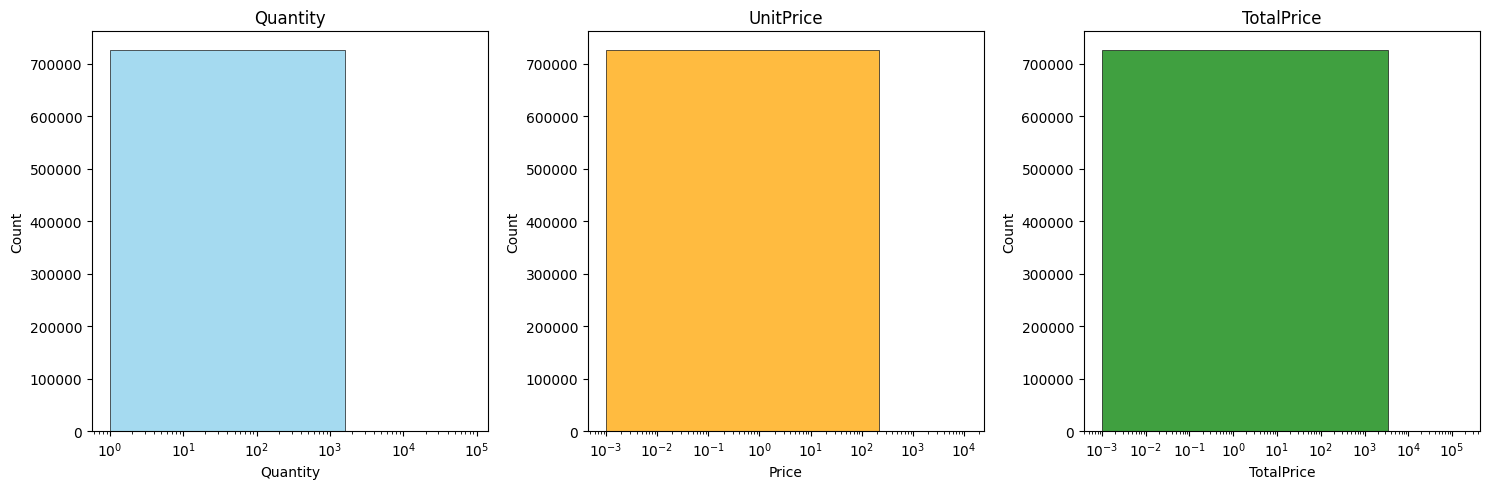

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df["Quantity"], bins=50, ax=ax[0], color="skyblue")
ax[0].set_title("Quantity")
ax[0].set_xscale("log")

sns.histplot(df["Price"], bins=50, ax=ax[1], color="orange")
ax[1].set_title("UnitPrice")
ax[1].set_xscale("log")

sns.histplot(df["TotalPrice"], bins=50, ax=ax[2], color="green")
ax[2].set_title("TotalPrice")
ax[2].set_xscale("log")

plt.tight_layout()
plt.show()


## Top 10 Countries by Order Count

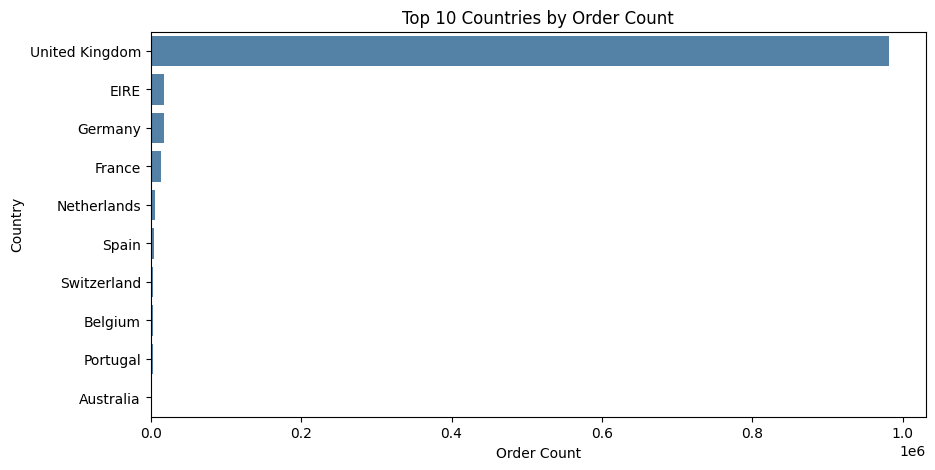

In [13]:
top10 = original_data["Country"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top10.values, y=top10.index, color="steelblue")
plt.title("Top 10 Countries by Order Count")
plt.xlabel("Order Count")
plt.ylabel("Country")
plt.show()


## Number of Transactions per month

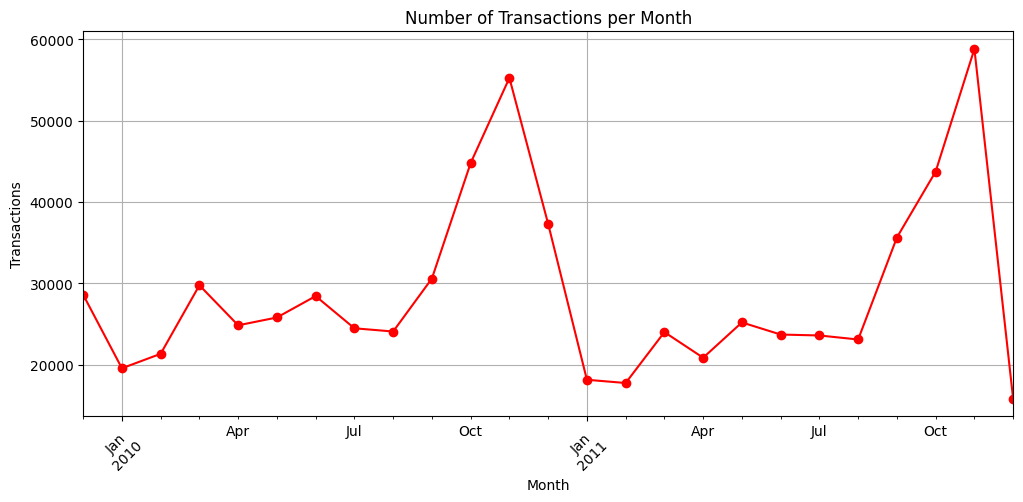

In [14]:
monthly_transactions = df.groupby(df["InvoiceDate"].dt.to_period("M")).size()

plt.figure(figsize=(12, 5))
monthly_transactions.plot(kind="line", marker="o", color="red")
plt.title("Number of Transactions per Month")
plt.xlabel("Month")
plt.ylabel("Transactions")
plt.xticks(rotation=45)
plt.grid()
plt.show()

### Seasonal Spikes

Yes, there are clear seasonal spikes in the number of transactions.

- Transactions increase significantly during October and November.
- The highest peak occurs in November 2011, with nearly 59,000 transactions.
- A similar increase can be seen in October–November 2010.
- This suggests a strong year-end/holiday shopping effect, with transaction activity rising toward the holiday season.
- Transactions drop sharply after November/December.

Conclusion: The dataset shows a clear seasonal pattern, with the strongest transaction activity occurring around October–November.

## 1.3 : Customer Level Analysis

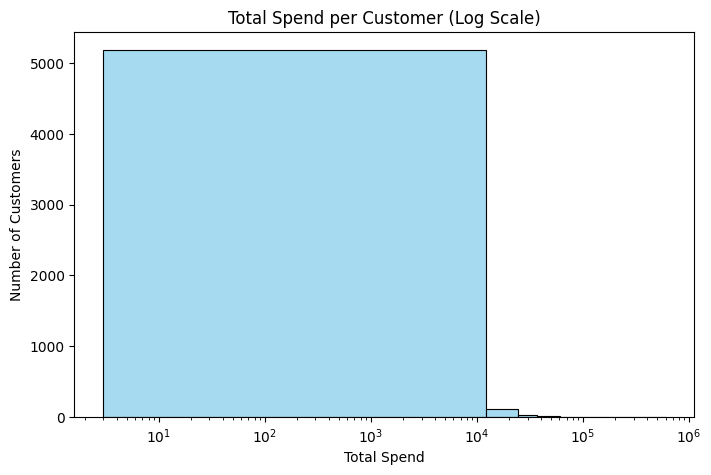

In [15]:
customer_spend = df.groupby("Customer ID")["TotalPrice"].sum()

plt.figure(figsize=(8, 5))
sns.histplot(customer_spend, bins=50, color="skyblue")
plt.xscale("log")
plt.title("Total Spend per Customer (Log Scale)")
plt.xlabel("Total Spend")
plt.ylabel("Number of Customers")
plt.show()

## Top 10 Highest Frequency Buyers

In [16]:
order_count = df.groupby("Customer ID")["Invoice"].nunique()

top_10_buyers = order_count.sort_values(ascending=False).head(10)

print("Top 10 Highest-Frequency Buyers:")
print(top_10_buyers)

Top 10 Highest-Frequency Buyers:
Customer ID
12748.0    336
17841.0    211
15311.0    208
13089.0    203
14606.0    192
17850.0    155
18102.0    145
13694.0    143
15061.0    127
14527.0    122
Name: Invoice, dtype: int64


In [17]:
unique_customers = df["Customer ID"].nunique()

print("Unique customers after cleaning:", unique_customers)

Unique customers after cleaning: 5350


# Task 2 :  RFM Feature Engineering & Preprocessing

## 2.1 : Build RFM Table

In [18]:
reference_date = pd.Timestamp("2011-12-31")

rfm_df = df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("TotalPrice", "sum")
).reset_index()

print(rfm_df)

      Customer ID  Recency  Frequency  Monetary
0         12346.0      346         12  77556.46
1         12608.0      425          1    415.79
2         12745.0      507          2    723.85
3         12746.0      561          1    254.55
4         12747.0       23         26   9276.54
...           ...      ...        ...       ...
5345      18283.0       24         22   2736.65
5346      18284.0      452          1    461.68
5347      18285.0      681          1    427.00
5348      18286.0      497          2   1296.43
5349      18287.0       63          7   4182.99

[5350 rows x 4 columns]


In [19]:
print("\nRFM Description:")
print(rfm_df.describe())


RFM Description:
        Customer ID      Recency    Frequency       Monetary
count   5350.000000  5350.000000  5350.000000    5350.000000
mean   15557.362617   223.546168     6.269346    2751.990190
std     1581.161762   209.973818    11.995550   12080.466564
min    12346.000000    21.000000     1.000000       2.950000
25%    14191.250000    46.000000     1.000000     336.167500
50%    15565.500000   119.000000     3.000000     849.910000
75%    16922.750000   402.000000     7.000000    2214.905000
max    18287.000000   759.000000   336.000000  608821.650000


In [20]:
print("\nRFM Skewness:")
print(rfm_df[["Recency", "Frequency", "Monetary"]].skew())


RFM Skewness:
Recency       0.871993
Frequency    10.433090
Monetary     28.971352
dtype: float64


## 2.2 : Outlier Handling

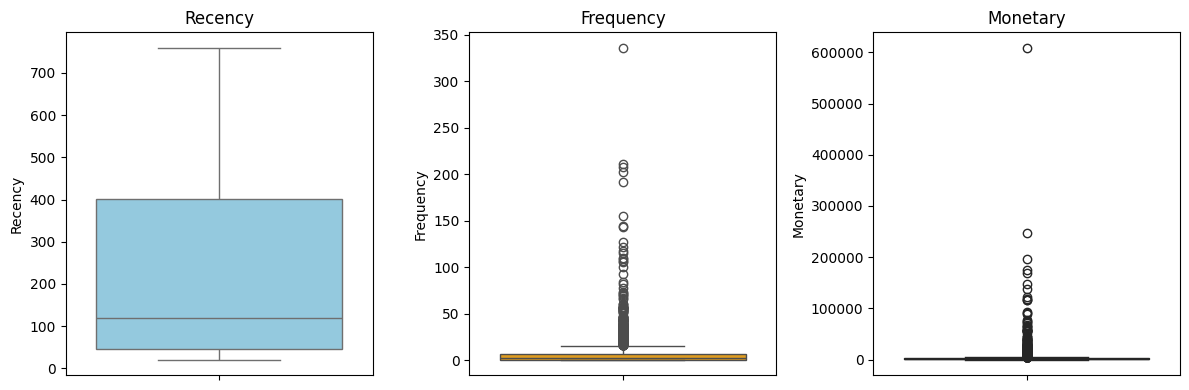

In [21]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.boxplot(y=rfm_df["Recency"], color="skyblue")
plt.title("Recency")

plt.subplot(1, 3, 2)
sns.boxplot(y=rfm_df["Frequency"], color="orange")
plt.title("Frequency")

plt.subplot(1, 3, 3)
sns.boxplot(y=rfm_df["Monetary"], color="green")
plt.title("Monetary")

plt.tight_layout()
plt.show()

In [22]:
for col in ["Recency", "Frequency", "Monetary"]:
    Q1 = rfm_df[col].quantile(0.25)
    Q3 = rfm_df[col].quantile(0.75)
    IQR = Q3 - Q1

    upper_limit = Q3 + 3 * IQR

    rfm_df[col] = rfm_df[col].clip(upper=upper_limit)

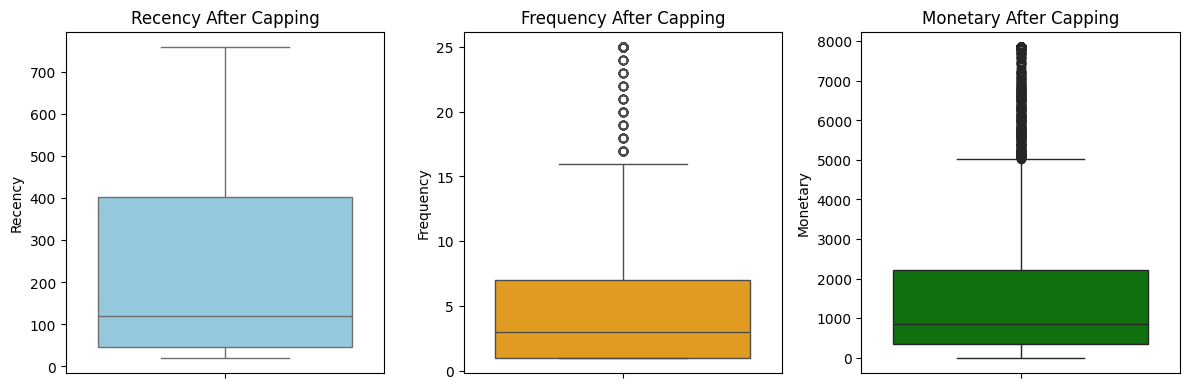

In [23]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.boxplot(y=rfm_df["Recency"], color="skyblue")
plt.title("Recency After Capping")

plt.subplot(1, 3, 2)
sns.boxplot(y=rfm_df["Frequency"], color="orange")
plt.title("Frequency After Capping")

plt.subplot(1, 3, 3)
sns.boxplot(y=rfm_df["Monetary"], color="green")
plt.title("Monetary After Capping")

plt.tight_layout()
plt.show()

## 2.3 : Transform Skewed Features

## Histograms before transformation

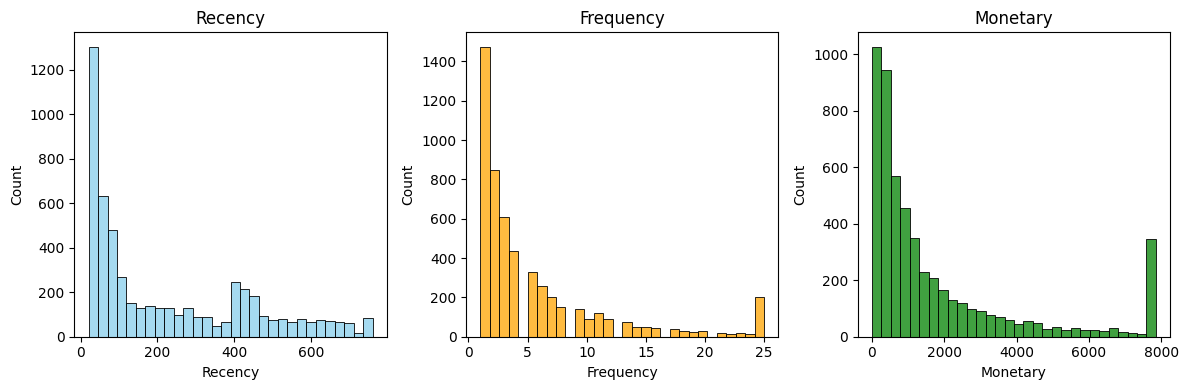

In [24]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.histplot(rfm_df["Recency"], bins=30, color="skyblue")
plt.title("Recency")

plt.subplot(1, 3, 2)
sns.histplot(rfm_df["Frequency"], bins=30, color="orange")
plt.title("Frequency")

plt.subplot(1, 3, 3)
sns.histplot(rfm_df["Monetary"], bins=30, color="green")
plt.title("Monetary")

plt.tight_layout()
plt.show()

## Log1p Transformation

In [25]:
rfm_df["Frequency"] = np.log1p(rfm_df["Frequency"])
rfm_df["Monetary"] = np.log1p(rfm_df["Monetary"])

## Histograms After Transformation

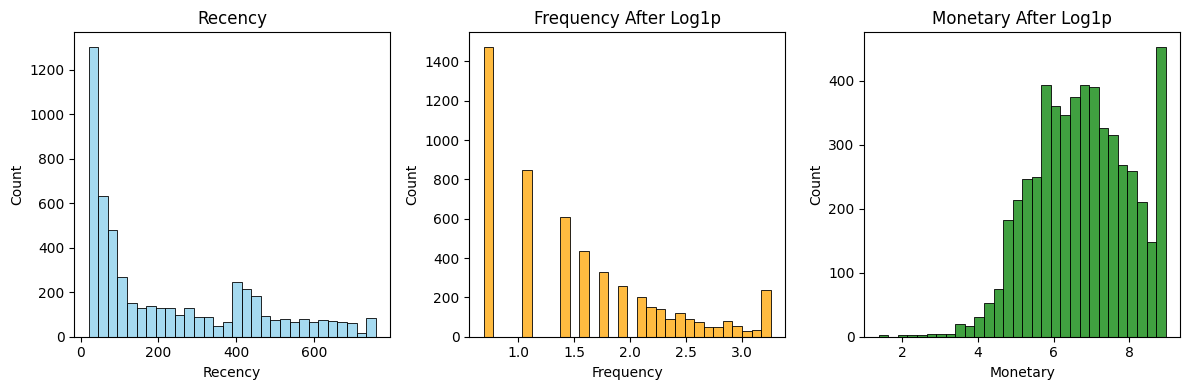

In [26]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.histplot(rfm_df["Recency"], bins=30, color="skyblue")
plt.title("Recency")

plt.subplot(1, 3, 2)
sns.histplot(rfm_df["Frequency"], bins=30, color="orange")
plt.title("Frequency After Log1p")

plt.subplot(1, 3, 3)
sns.histplot(rfm_df["Monetary"], bins=30, color="green")
plt.title("Monetary After Log1p")

plt.tight_layout()
plt.show()

### Transformation Result

Recency was kept unchanged because the task only requires log1p transformation for Frequency and Monetary.

After applying log1p, Frequency and Monetary are less right-skewed and more symmetrical.

## 2.4 : Scale The Features

In [27]:
features = rfm_df[["Recency", "Frequency", "Monetary"]]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(features)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency_log", "Monetary_log"]
)

print("Mean:")
print(rfm_scaled.mean())

print("\nStandard Deviation:")
print(rfm_scaled.std())

Mean:
Recency         -2.224596e-17
Frequency_log    3.927907e-16
Monetary_log     3.214044e-16
dtype: float64

Standard Deviation:
Recency          1.000093
Frequency_log    1.000093
Monetary_log     1.000093
dtype: float64


# Step 3 : K-Means Clustering

## 3.1 : Elbow Method - Find Optimal K

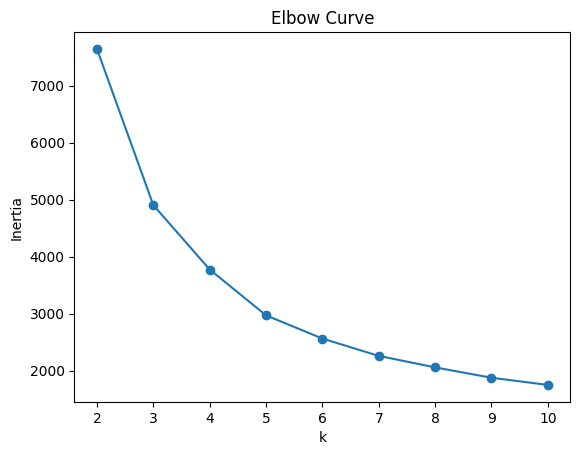

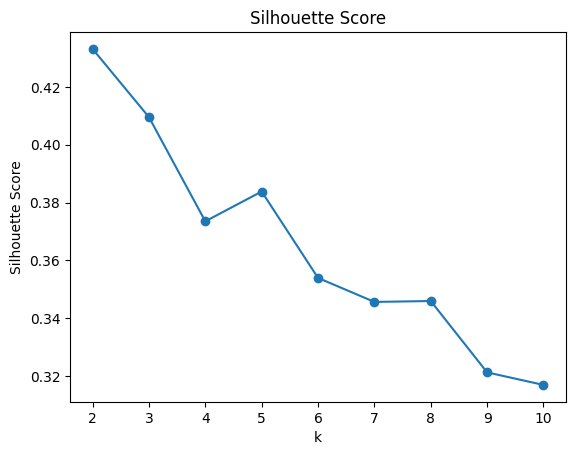

In [28]:
inertia = []
silhouette = []

for k in range(2, 11):

    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)

    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(rfm_scaled, labels))


plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Curve")
plt.show()

plt.plot(range(2, 11), silhouette, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.show()

### Optimal Number of Clusters

The Silhouette Score is highest at k = 2, but k = 3 also has a strong Silhouette Score. The Elbow Curve shows a clear bend around k = 3, after which the improvement in inertia becomes smaller. Therefore, k = 3 is selected as the optimal number of clusters because it provides a good balance between cluster quality and meaningful customer segmentation.

## 3.2 : Train final K-Means Model

In [29]:
k_optimal = 3

kmeans = KMeans(n_clusters=k_optimal,init="k-means++",n_init=20,max_iter=500,random_state=42)

rfm_df["KMeans_Cluster"] = kmeans.fit_predict(rfm_scaled)

print(rfm_df.head())

   Customer ID  Recency  Frequency  Monetary  KMeans_Cluster
0      12346.0      346   2.564949  8.968539               1
1      12608.0      425   0.693147  6.032582               0
2      12745.0      507   1.098612  6.585965               0
3      12746.0      561   0.693147  5.543418               0
4      12747.0       23   3.258097  8.968539               1


## 3.3 : Visualize K-Means Clusters

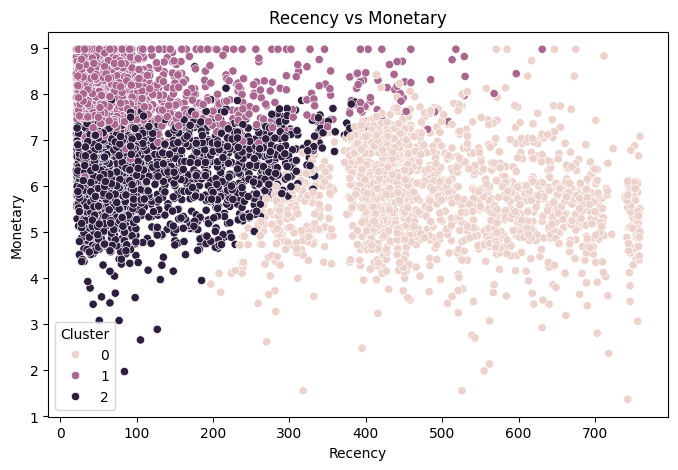

In [30]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm_df,
    x="Recency",
    y="Monetary",
    hue="KMeans_Cluster"
)

plt.title("Recency vs Monetary")
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.legend(title="Cluster")
plt.show()

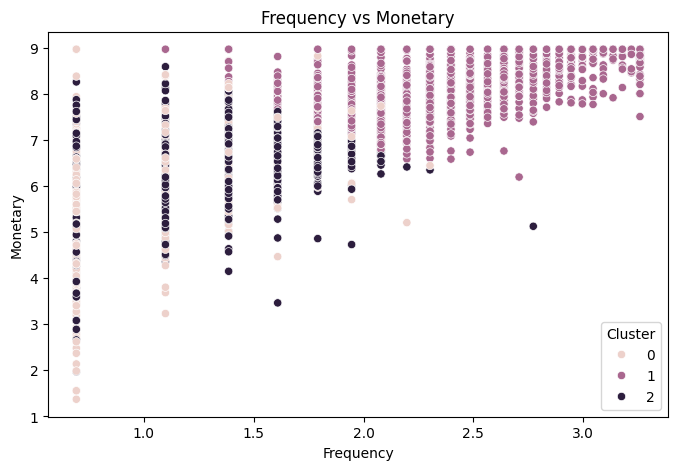

In [31]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm_df,
    x="Frequency",
    y="Monetary",
    hue="KMeans_Cluster"
)

plt.title("Frequency vs Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.legend(title="Cluster")
plt.show()


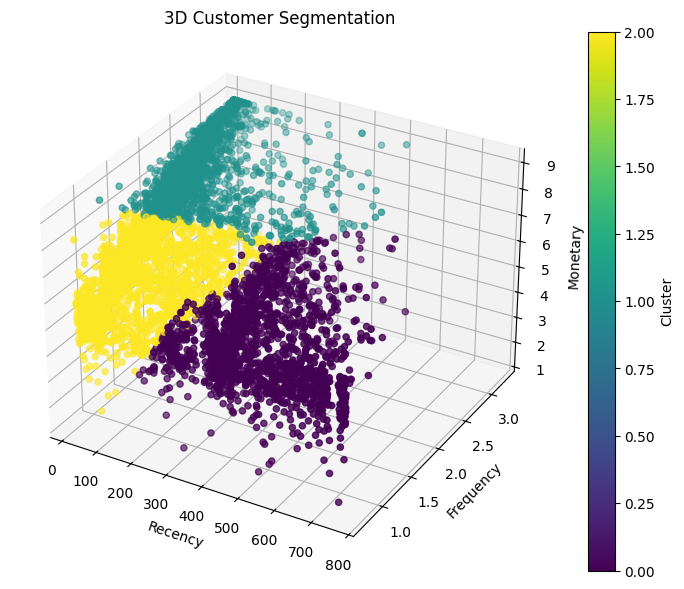

In [32]:
fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    rfm_df["Recency"],
    rfm_df["Frequency"],
    rfm_df["Monetary"],
    c=rfm_df["KMeans_Cluster"],
    cmap="viridis"
)

ax.set_title("3D Customer Segmentation")
ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")

plt.colorbar(scatter, label="Cluster")
plt.show()

## 3.4 : Profile The K-Means Clusters

In [33]:
cluster_profile = rfm_df.groupby("KMeans_Cluster")[[
    "Recency", "Frequency", "Monetary"
]].mean().sort_values("Monetary", ascending=False)

cluster_profile = cluster_profile.round(2)

print(cluster_profile)

                Recency  Frequency  Monetary
KMeans_Cluster                              
1                 86.15       2.45      8.16
2                112.90       1.23      6.34
0                495.58       0.95      5.78


# Step 4 : Agglomerative Hierarchical Clustering

## 4.1 : Dendrogram Analysis

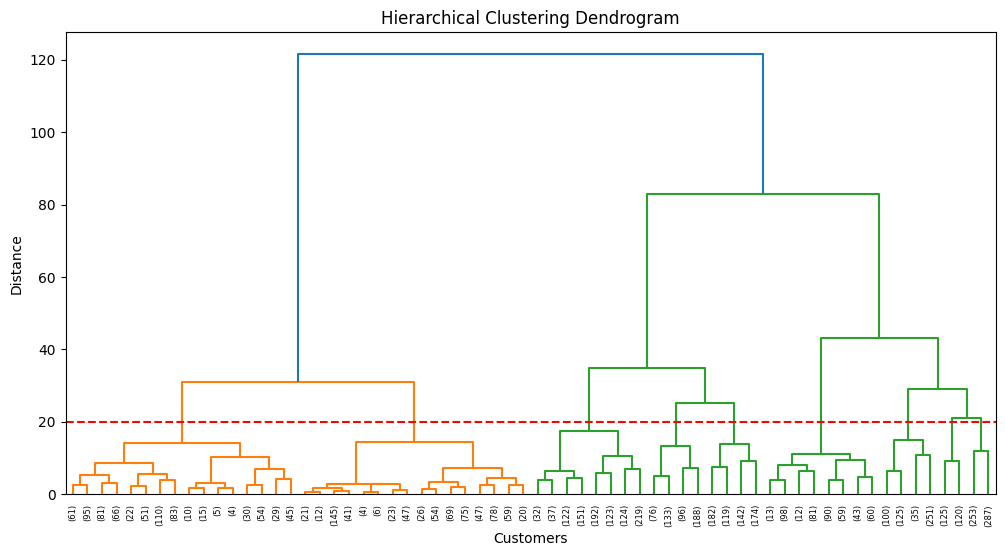

In [34]:
linkage_matrix = linkage(rfm_scaled, method="ward")

plt.figure(figsize=(12, 6))

dendrogram(linkage_matrix,truncate_mode="level",p=5)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")

cut = 20
plt.axhline(y=cut, color="red", linestyle="--")

plt.show()

In [35]:
n = len(rfm_scaled)

lower = linkage_matrix[n - 4, 2]
upper = linkage_matrix[n - 3, 2]

cut_3 = (lower + upper) / 2

clusters_3 = fcluster(linkage_matrix,cut_3,criterion="distance")

print("Cut distance for 3 clusters:", cut_3)
print("Number of clusters:", len(set(clusters_3)))

Cut distance for 3 clusters: 63.02846936120518
Number of clusters: 3


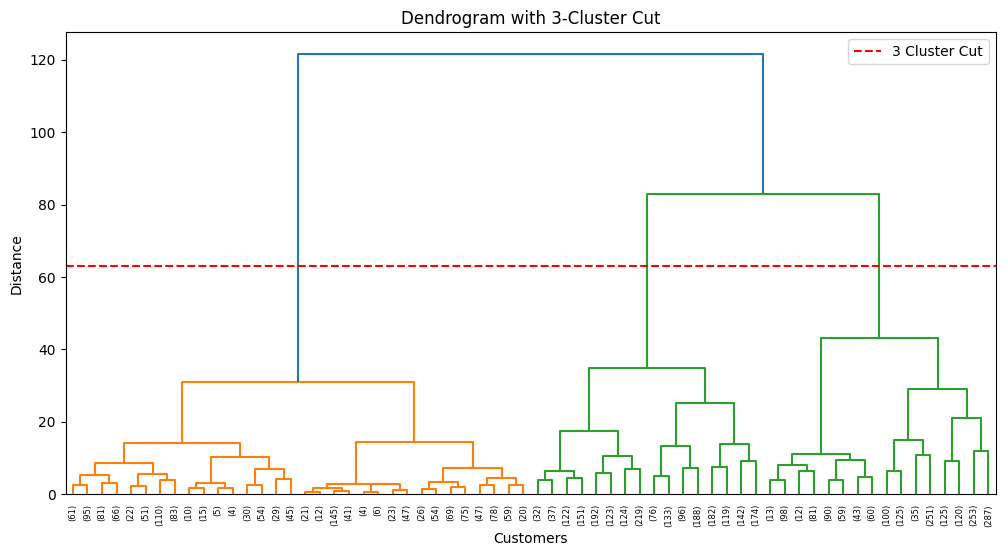

In [36]:
plt.figure(figsize=(12, 6))

dendrogram(linkage_matrix,truncate_mode="level",p=5)

plt.axhline(y=cut_3,color="red",linestyle="--",label="3 Cluster Cut")

plt.title("Dendrogram with 3-Cluster Cut")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.legend()

plt.show()

### Dendrogram Analysis

The hierarchical clustering dendrogram was created using Ward linkage. A horizontal cut was applied at the selected distance threshold, producing 3 clusters, which is consistent with the K-Means solution selected earlier.

## 4.2 : Train Agglomerative Model

### Using linkage = 'ward'

In [37]:
n_chosen = 3

ward_model = AgglomerativeClustering(n_clusters=n_chosen,linkage="ward")
ward_labels = ward_model.fit_predict(rfm_scaled)
ward_score = silhouette_score(rfm_scaled, ward_labels)

### Using linkage = 'complete'

In [38]:
complete_model = AgglomerativeClustering(n_clusters=n_chosen,linkage="complete")
complete_labels = complete_model.fit_predict(rfm_scaled)
complete_score = silhouette_score(rfm_scaled, complete_labels)

### Using linkage = 'average'

In [39]:
average_model = AgglomerativeClustering(n_clusters=n_chosen,linkage="average")
average_labels = average_model.fit_predict(rfm_scaled)
average_score = silhouette_score(rfm_scaled, average_labels)

In [40]:
scores = {
    "ward": ward_score,
    "complete": complete_score,
    "average": average_score
}

best_linkage = max(scores, key=scores.get)

print("Best Linkage:", best_linkage)

if best_linkage == "ward":
    rfm_df["Agg_Cluster"] = ward_labels
elif best_linkage == "complete":
    rfm_df["Agg_Cluster"] = complete_labels
else:
    rfm_df["Agg_Cluster"] = average_labels

print(rfm_df[["Customer ID", "Agg_Cluster"]].head())

Best Linkage: ward
   Customer ID  Agg_Cluster
0      12346.0            1
1      12608.0            0
2      12745.0            0
3      12746.0            0
4      12747.0            1


## 4.3 : Visualize and Profile Hierachical Clusters

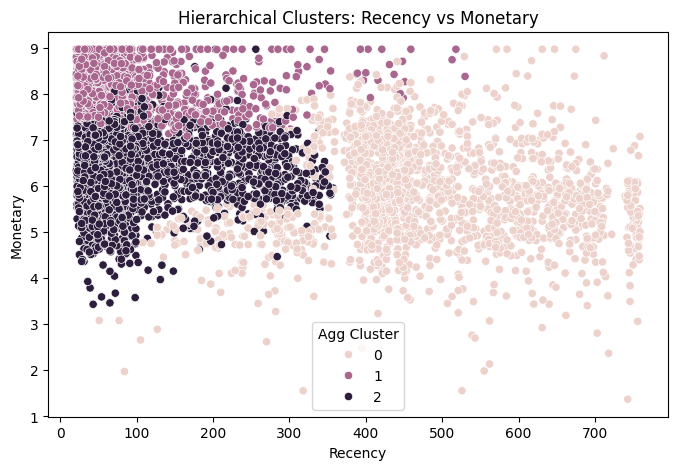

In [41]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=rfm_df,x="Recency",y="Monetary",hue="Agg_Cluster")

plt.title("Hierarchical Clusters: Recency vs Monetary")
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.legend(title="Agg Cluster")
plt.show()

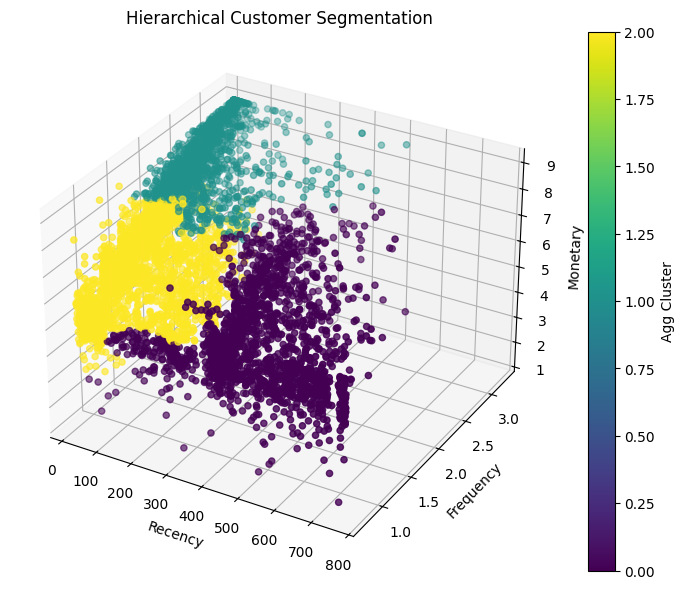

In [42]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    rfm_df["Recency"],
    rfm_df["Frequency"],
    rfm_df["Monetary"],
    c=rfm_df["Agg_Cluster"],
    cmap="viridis"
)

ax.set_title("Hierarchical Customer Segmentation")
ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")

plt.colorbar(scatter, label="Agg Cluster")
plt.show()

In [43]:
agg_profile = rfm_df.groupby("Agg_Cluster")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean().sort_values("Monetary", ascending=False)

agg_profile = agg_profile.round(2)

print(agg_profile)

             Recency  Frequency  Monetary
Agg_Cluster                              
1              77.81       2.53      8.28
2             109.34       1.29      6.44
0             484.86       0.99      5.83


In [44]:
comparison = pd.crosstab(
    rfm_df["KMeans_Cluster"],
    rfm_df["Agg_Cluster"]
)

print(comparison)

Agg_Cluster        0     1     2
KMeans_Cluster                  
0               1580     0    88
1                 56  1464   213
2                116    24  1809


### Comparison of K-Means and Hierarchical Clusters

The Hierarchical clusters largely match the K-Means clusters, with most customers staying in the same corresponding groups. The strongest agreement is between K-Means Cluster 0 and Agglomerative Cluster 0, and between K-Means Cluster 2 and Agglomerative Cluster 2. Some customers are assigned differently, especially around the boundaries of the clusters, showing that the two methods identify slightly different segment memberships.

# Step 5 : DBSCAN Clustering

## 5.1 : Tune Epsilon Using k-NN Distance Plot

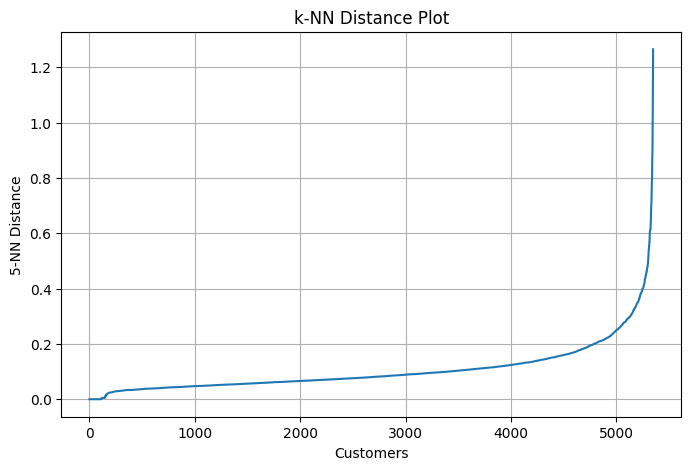

In [45]:
min_pts = 5

neighbors = NearestNeighbors(n_neighbors=min_pts)
neighbors.fit(rfm_scaled)

distances, indices = neighbors.kneighbors(rfm_scaled)

k_distances = distances[:, min_pts - 1]

k_distances = np.sort(k_distances)

plt.figure(figsize=(8, 5))
plt.plot(k_distances)

plt.xlabel("Customers")
plt.ylabel("5-NN Distance")
plt.title("k-NN Distance Plot")
plt.grid()
plt.show()

### Markdown justification

The k-NN distance curve shows an elbow at approximately epsilon = 0.25, where the distance begins to increase more rapidly. Therefore, 0.25 is selected as the optimal epsilon for DBSCAN.

## 5.2 : Train DBSCAN Model

In [46]:
optimal_eps = 0.25

dbscan = DBSCAN(eps=optimal_eps,min_samples=5,metric="euclidean")

rfm_df["DBSCAN_Cluster"] = dbscan.fit_predict(rfm_scaled)

num_clusters = len(set(rfm_df["DBSCAN_Cluster"])) - 1

noise_points = (rfm_df["DBSCAN_Cluster"] == -1).sum()

noise_percentage = (noise_points / len(rfm_df)) * 100

print("Number of clusters:", num_clusters)
print("Number of noise points:", noise_points)
print("Percentage of noise:", round(noise_percentage, 2), "%")

Number of clusters: 8
Number of noise points: 231
Percentage of noise: 4.32 %


## 5.3 : Tune DBSCAN Hyperparameters

In [47]:
eps_values = [0.3, 0.5, 0.7, 1.0, 1.5]
min_samples_values = [3, 5, 8, 10]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric="euclidean"
        )

        labels = dbscan.fit_predict(rfm_scaled)

        non_noise = labels != -1

        if len(set(labels[non_noise])) >= 2:
            score = silhouette_score(
                rfm_scaled[non_noise],
                labels[non_noise]
            )
        else:
            score = -1

        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "Silhouette_Score": score
        })

dbscan_results = pd.DataFrame(results)

print(dbscan_results)

    eps  min_samples  Silhouette_Score
0   0.3            3          0.005152
1   0.3            5          0.105491
2   0.3            8          0.198689
3   0.3           10          0.201054
4   0.5            3          0.304084
5   0.5            5          0.333463
6   0.5            8          0.333440
7   0.5           10          0.333265
8   0.7            3         -1.000000
9   0.7            5         -1.000000
10  0.7            8         -1.000000
11  0.7           10         -1.000000
12  1.0            3         -1.000000
13  1.0            5         -1.000000
14  1.0            8         -1.000000
15  1.0           10         -1.000000
16  1.5            3         -1.000000
17  1.5            5         -1.000000
18  1.5            8         -1.000000
19  1.5           10         -1.000000


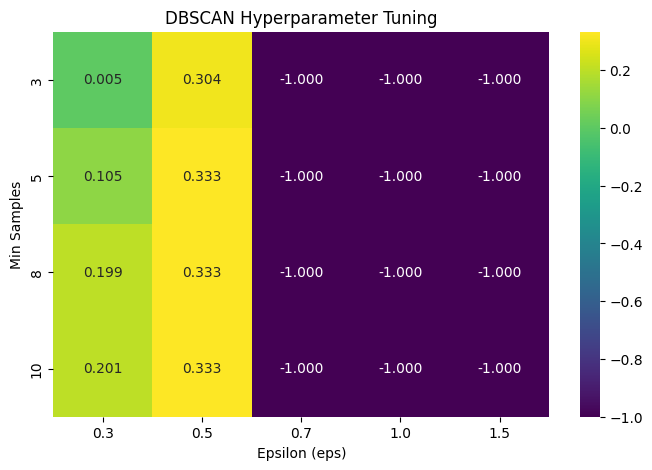

In [48]:
heatmap_data = dbscan_results.pivot(index="min_samples",columns="eps",values="Silhouette_Score")

plt.figure(figsize=(8, 5))

sns.heatmap(heatmap_data,annot=True,fmt=".3f",cmap="viridis")

plt.title("DBSCAN Hyperparameter Tuning")
plt.xlabel("Epsilon (eps)")
plt.ylabel("Min Samples")
plt.show()

In [49]:
optimal_eps = 0.5
optimal_min_samples = 5

dbscan_final = DBSCAN(eps=optimal_eps,min_samples=optimal_min_samples,metric="euclidean")

rfm_df["DBSCAN_Cluster"] = dbscan_final.fit_predict(rfm_scaled)

print(rfm_df["DBSCAN_Cluster"].value_counts())

DBSCAN_Cluster
 0    3859
 1    1465
-1      26
Name: count, dtype: int64


## 5.4 : Visualise & Profile DBSCAN Clusters

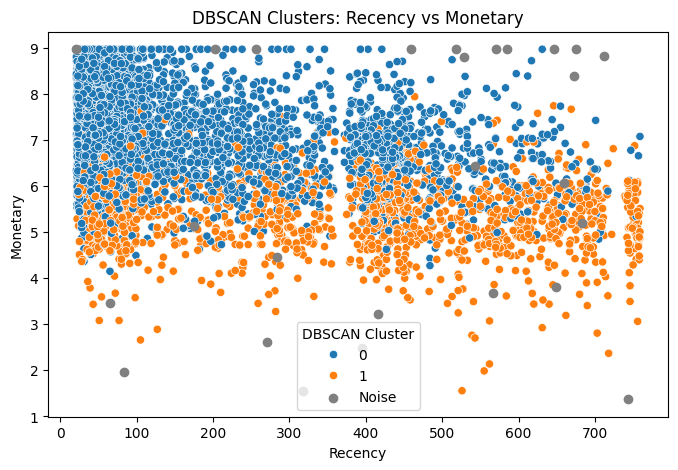

In [50]:
plt.figure(figsize=(8, 5))

normal = rfm_df[rfm_df["DBSCAN_Cluster"] != -1]

sns.scatterplot(data=normal,x="Recency",y="Monetary",hue="DBSCAN_Cluster",palette="tab10")

noise = rfm_df[rfm_df["DBSCAN_Cluster"] == -1]

plt.scatter(noise["Recency"],noise["Monetary"],color="grey",label="Noise")

plt.title("DBSCAN Clusters: Recency vs Monetary")
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.legend(title="DBSCAN Cluster")
plt.show()

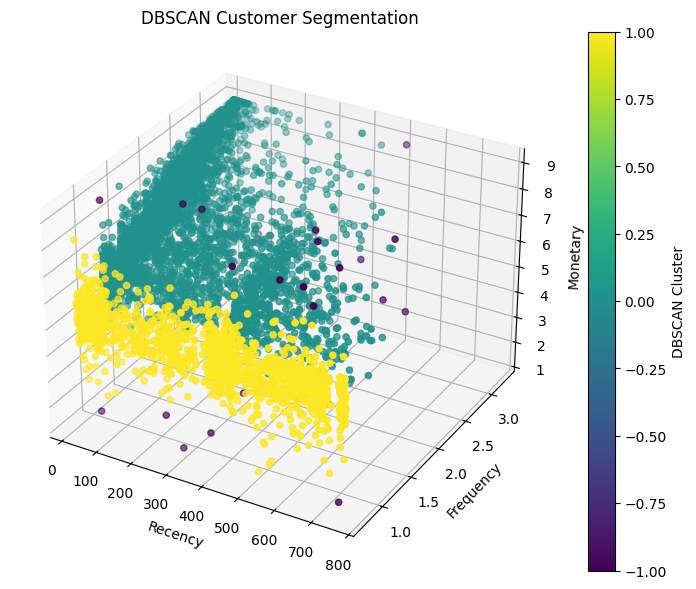

In [51]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    rfm_df["Recency"],
    rfm_df["Frequency"],
    rfm_df["Monetary"],
    c=rfm_df["DBSCAN_Cluster"],
    cmap="viridis"
)

ax.set_title("DBSCAN Customer Segmentation")
ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")

plt.colorbar(scatter, label="DBSCAN Cluster")
plt.show()

In [52]:
dbscan_profile = rfm_df[
    rfm_df["DBSCAN_Cluster"] != -1
].groupby("DBSCAN_Cluster")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean()

dbscan_profile = dbscan_profile.round(2)

dbscan_profile = dbscan_profile.sort_values(
    "Monetary",
    ascending=False
)

print(dbscan_profile)

                Recency  Frequency  Monetary
DBSCAN_Cluster                              
0                163.05       1.86      7.27
1                378.87       0.69      5.41


### Marketing team Analysis

DBSCAN identified noise customers as customers with unusual RFM behaviour that did not fit into the main customer groups. These may include customers with unusually high or low Recency, Frequency, or Monetary values. For the marketing team, these customers should be analysed separately and given more personalised marketing strategies, rather than being treated as part of the standard customer segments.

# Step 6 : Algorithm Comparison & Business Interpretation

## 6.1 : Internal Metrics Comparison Table

In [53]:
kmeans_silhouette = silhouette_score(rfm_scaled,rfm_df["KMeans_Cluster"])

kmeans_clusters = rfm_df["KMeans_Cluster"].nunique()

agg_silhouette = silhouette_score(rfm_scaled,rfm_df["Agg_Cluster"])

agg_clusters = rfm_df["Agg_Cluster"].nunique()

dbscan_labels = rfm_df["DBSCAN_Cluster"]

non_noise = dbscan_labels != -1

dbscan_silhouette = silhouette_score(rfm_scaled[non_noise],dbscan_labels[non_noise])

dbscan_clusters = len(set(dbscan_labels)) - 1

noise_percentage = ((dbscan_labels == -1).sum()/ len(dbscan_labels)) * 100


comparison_table = pd.DataFrame({
    "Algorithm": ["KMeans","Agglomerative","DBSCAN"],
    "Final Hyperparameters": [
        "n_clusters=3, n_init=20, max_iter=500",
        "n_clusters=3, linkage=best_linkage",
        "eps=0.5, min_samples=5"
    ],
    "Number of Clusters": [ kmeans_clusters, agg_clusters, dbscan_clusters],
    "Silhouette Score": [kmeans_silhouette,agg_silhouette,dbscan_silhouette],
    "Noise %": [0,0,noise_percentage]
})

comparison_table["Silhouette Score"] = comparison_table["Silhouette Score"].round(3)
comparison_table["Noise %"] = comparison_table["Noise %"].round(2)

comparison_table

,Algorithm,Final Hyperparameters,Number of Clusters,Silhouette Score,Noise %
0,KMeans,"n_clusters=3, n_init=20, max_iter=500",3,0.409,0.00
1,Agglomerative,"n_clusters=3, linkage=best_linkage",3,0.386,0.00
2,DBSCAN,"eps=0.5, min_samples=5",2,0.333,0.49


## 6.2 : Cluster Stability Check for K-Means

In [54]:
random_states = [0, 7, 21, 42, 99]

silhouette_scores = []

for state in random_states:

    kmeans = KMeans(n_clusters=3,init="k-means++",n_init=20,max_iter=500,random_state=state)

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)

    silhouette_scores.append(score)

    print("Random State:", state)
    print("Silhouette Score:", round(score, 4))
    print()

Random State: 0
Silhouette Score: 0.4094

Random State: 7
Silhouette Score: 0.4097

Random State: 21
Silhouette Score: 0.4097

Random State: 42
Silhouette Score: 0.4095

Random State: 99
Silhouette Score: 0.4097



In [55]:
mean_score = np.mean(silhouette_scores)
std_score = np.std(silhouette_scores)

print("Mean Silhouette Score:", round(mean_score, 4))
print("Standard Deviation:", round(std_score, 4))
print("Mean ± Std:", round(mean_score, 4), "±", round(std_score, 4))

Mean Silhouette Score: 0.4096
Standard Deviation: 0.0002
Mean ± Std: 0.4096 ± 0.0002


### Result Interpretation

K-Means demonstrated high cluster stability across different random states, with a mean Silhouette Score of 0.4096 ± 0.0002. The very low standard deviation indicates that the clustering results vary negligibly across runs, confirming that the selected K-Means solution is stable.

## 6.3 Business Recommendation

### Recommendation to the Marketing Director

Based on the RFM-based customer segmentation analysis, K-Means Clustering is recommended for deployment. K-Means provides a clear and practical segmentation of customers based on their Recency, Frequency, and Monetary (RFM) behaviour. It is also highly stable across different random states, with a mean Silhouette Score of 0.4096 ± 0.0002. The very small standard deviation shows that the clustering quality remains almost unchanged across different runs, making the solution reliable for business use.

The analysis identified 3 customer segments. These segments can be used by the marketing team to design targeted campaigns instead of applying the same marketing strategy to all customers.

Champions ---> Customers who purchase frequently and generate high monetary value, making them the most valuable and engaged customers. Invite them to an exclusive loyalty programme with early access to sales, premium benefits, and special rewards.
Loyal Customers ---> Customers who show regular purchasing behaviour and provide consistent business value, but are not the highest-value group. Offer personalised discounts or reward points** to encourage repeat purchases and increase their purchase frequency.
At-Risk Customers ---> Customers whose purchasing activity has reduced or who have not purchased recently, creating a risk of customer loss. Send a targeted re-engagement offer**, such as a 20% discount coupon with a 7-day expiry, to encourage them to return. 

### Additional Data for Future Segmentation

RFM provides a useful view of customer purchasing behaviour, but segmentation quality could be improved by incorporating additional customer and transaction information. Useful variables would include:

- Customer demographics – age, gender, and location.
- Product preferences – categories and types of products purchased.
- Average order value – to understand typical spending per transaction.
- Discount and coupon usage – to identify price-sensitive customers.
- Purchase channel – website, mobile app, or other channels.
- Customer returns and cancellations – to identify customers with frequent returns or cancelled orders.
- Customer engagement – website/app visits, clicks, and browsing behaviour.
- Customer satisfaction – ratings, reviews, complaints, and support interactions.

Adding these variables in the next iteration would allow the business to move beyond purely transaction-based RFM segmentation and create more detailed, behaviour-based customer segments. This would enable Flipkart/Meesho to deliver more personalised marketing campaigns and improve customer lifetime value.

#  Step 7 : Pipeline & Deployment 

## 7.1 : Save the Final Clustering Pipeline

In [56]:
best_model = kmeans

joblib.dump(scaler, "rfm_scaler.pkl")
joblib.dump(best_model, "customer_segmentation_model.pkl")

print("Scaler saved successfully.")
print("Clustering model saved successfully.")

Scaler saved successfully.
Clustering model saved successfully.


In [57]:
cluster_personas = {
    1: "Champions",
    2: "Loyal Customers",
    0: "Hibernating Customers"
}

In [58]:
def predict_segment(recency, frequency, monetary):

    frequency = np.log1p(frequency)
    monetary = np.log1p(monetary)

    new_customer = pd.DataFrame({
        "Recency": [recency],
        "Frequency": [frequency],
        "Monetary": [monetary]
    })

    new_customer_scaled = scaler.transform(new_customer)

    cluster = best_model.predict(new_customer_scaled)[0]


    persona = cluster_personas[cluster]

    return cluster, persona

In [59]:
new_customers = [
    {"Recency": 15, "Frequency": 12, "Monetary": 2000},
    {"Recency": 30, "Frequency": 8, "Monetary": 1200},
    {"Recency": 100, "Frequency": 3, "Monetary": 500},
    {"Recency": 500, "Frequency": 1, "Monetary": 100},
    {"Recency": 150, "Frequency": 2, "Monetary": 300}
]

for customer in new_customers:

    cluster, persona = predict_segment(
        customer["Recency"],
        customer["Frequency"],
        customer["Monetary"]
    )

    print("RFM:", customer)
    print("Cluster:", cluster)
    print("Persona:", persona)
    print("-" * 40)

RFM: {'Recency': 15, 'Frequency': 12, 'Monetary': 2000}
Cluster: 0
Persona: Hibernating Customers
----------------------------------------
RFM: {'Recency': 30, 'Frequency': 8, 'Monetary': 1200}
Cluster: 0
Persona: Hibernating Customers
----------------------------------------
RFM: {'Recency': 100, 'Frequency': 3, 'Monetary': 500}
Cluster: 1
Persona: Champions
----------------------------------------
RFM: {'Recency': 500, 'Frequency': 1, 'Monetary': 100}
Cluster: 2
Persona: Loyal Customers
----------------------------------------
RFM: {'Recency': 150, 'Frequency': 2, 'Monetary': 300}
Cluster: 1
Persona: Champions
----------------------------------------


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have